# Rețele neuronale și Backpropagation (de la zero)

În acest notebook construim o **rețea neuronală mică** folosind doar:
- `numpy` — calcule
- `pandas` — tabele
- `matplotlib` — vizualizări

**Fără** TensorFlow, PyTorch sau Keras.

Problema rămâne aceeași ca la gradient descent:  
**previziunea prețului unui apartament** pe baza suprafeței.

## Pasul 0 — Importuri

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

## Pasul 1 — Datele (apartamente)

Aceleași 10 apartamente: **suprafață (m²)** → **preț (€)**.

In [3]:
apartamente = np.array([
    (30, 54_000),
    (36, 75_000),
    (49, 120_000),
    (53, 175_000),
    (69, 193_000),
    (70, 215_000),
    (79, 210_000),
    (83, 245_000),
    (84, 284_000),
    (90, 345_000),
])

df = pd.DataFrame(apartamente, columns=["suprafata_m2", "pret_eur"])
df

,suprafata_m2,pret_eur
0,30,54000
1,36,75000
2,49,120000
3,53,175000
4,69,193000
5,70,215000
6,79,210000
7,83,245000
8,84,284000
9,90,345000


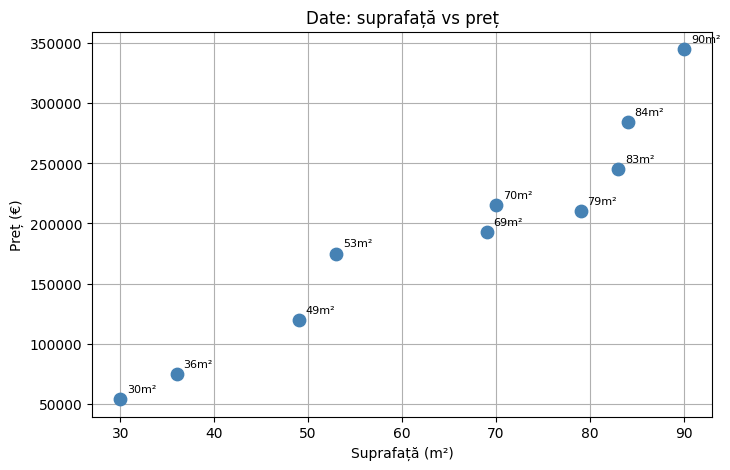

In [4]:
x = df["suprafata_m2"].values.astype(float)
y = df["pret_eur"].values.astype(float)
n = len(x)

plt.scatter(x, y, s=80, color="steelblue", zorder=3)
plt.xlabel("Suprafață (m²)")
plt.ylabel("Preț (€)")
plt.title("Date: suprafață vs preț")
for i in range(n):
    plt.annotate(f"{int(x[i])}m²", (x[i], y[i]), textcoords="offset points", xytext=(5, 5), fontsize=8)
plt.show()

## Pasul 2 — Ce este o rețea neuronală? (intuiție)

O rețea neuronală este un lanț de **transformări liniare** + **neliniarități**:

1. **Intrare** — aici: suprafața
2. **Strat(e) ascuns(e)** — neuroni care „amestecă” informația
3. **Ieșire** — aici: prețul prezis

Fiecare conexiune are o **greutate** (`w`). Fiecare neuron are un **bias** (`b`).

Vom construi o rețea foarte mică:

```
  [suprafață]  →  (2 neuroni ascunși)  →  [preț]
     1 input           2 hidden             1 output
```

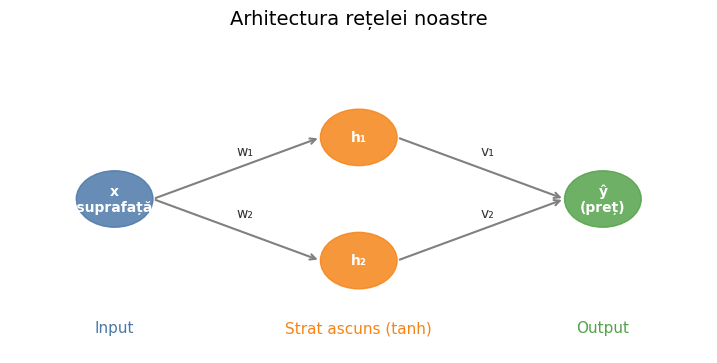

In [5]:
# Diagramă simplă a arhitecturii
fig, ax = plt.subplots(figsize=(9, 4))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis("off")
ax.set_title("Arhitectura rețelei noastre", fontsize=14, pad=15)

# Noduri
nodes = {
    "x":  (1.5, 3.0),
    "h1": (5.0, 4.2),
    "h2": (5.0, 1.8),
    "y":  (8.5, 3.0),
}
labels = {"x": "x\n(suprafață)", "h1": "h₁", "h2": "h₂", "y": "ŷ\n(preț)"}
colors = {"x": "#4C78A8", "h1": "#F58518", "h2": "#F58518", "y": "#54A24B"}

for name, (px, py) in nodes.items():
    circle = plt.Circle((px, py), 0.55, color=colors[name], alpha=0.85, zorder=3)
    ax.add_patch(circle)
    ax.text(px, py, labels[name], ha="center", va="center", color="white", fontsize=10, fontweight="bold", zorder=4)

# Conexiuni
edges = [("x", "h1", "w₁"), ("x", "h2", "w₂"), ("h1", "y", "v₁"), ("h2", "y", "v₂")]
for a, b, lab in edges:
    x1, y1 = nodes[a]
    x2, y2 = nodes[b]
    ax.annotate("", xy=(x2 - 0.55, y2), xytext=(x1 + 0.55, y1),
                arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))
    mx, my = (x1 + x2) / 2, (y1 + y2) / 2
    ax.text(mx, my + 0.25, lab, fontsize=10, color="#333")

ax.text(5.0, 0.4, "Strat ascuns (tanh)", ha="center", fontsize=11, color="#F58518")
ax.text(1.5, 0.4, "Input", ha="center", fontsize=11, color="#4C78A8")
ax.text(8.5, 0.4, "Output", ha="center", fontsize=11, color="#54A24B")
plt.show()

## Pasul 3 — Normalizare

Ca și la gradient descent, normalizăm datele ca antrenarea să fie stabilă.

$$x_{norm} = \frac{x - \bar{x}}{\sigma_x}, \quad y_{norm} = \frac{y - \bar{y}}{\sigma_y}$$

In [6]:
x_mean, x_std = x.mean(), x.std()
y_mean, y_std = y.mean(), y.std()

x_norm = (x - x_mean) / x_std
y_norm = (y - y_mean) / y_std

# Formă de coloană: (n, 1) — ușor de folosit în matrici
X = x_norm.reshape(-1, 1)
Y = y_norm.reshape(-1, 1)

pd.DataFrame({"x": x, "x_norm": x_norm.round(3), "y": y, "y_norm": y_norm.round(3)})

,x,x_norm,y,y_norm
0,30.0,-1.713,54000.0,-1.602
1,36.0,-1.414,75000.0,-1.358
2,49.0,-0.764,120000.0,-0.834
3,53.0,-0.564,175000.0,-0.193
4,69.0,0.235,193000.0,0.016
5,70.0,0.285,215000.0,0.272
6,79.0,0.734,210000.0,0.214
7,83.0,0.934,245000.0,0.622
8,84.0,0.984,284000.0,1.076
9,90.0,1.284,345000.0,1.786


## Pasul 4 — Funcția de activare

Fără activare, rețeaua ar fi doar o succesiune de înmulțiri de matrici → tot **liniară** (ca regresia liniară).

Folosim **tanh** pe stratul ascuns:

$$\tanh(z) = \frac{e^{z} - e^{-z}}{e^{z} + e^{-z}}$$

Derivata (necesară la backpropagation):

$$\tanh'(z) = 1 - \tanh(z)^2$$

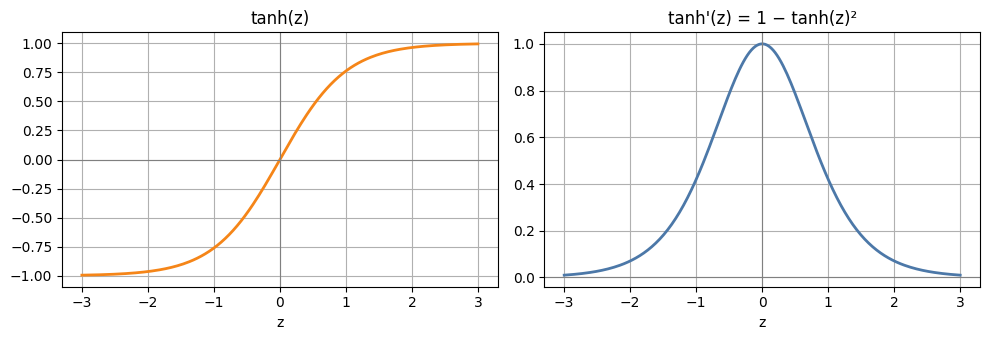

In [7]:
def tanh(z):
    return np.tanh(z)

def tanh_deriv(a):
    """Derivata tanh, exprimată în funcție de activarea a = tanh(z)."""
    return 1 - a ** 2

z_plot = np.linspace(-3, 3, 200)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].plot(z_plot, tanh(z_plot), color="#F58518", lw=2)
axes[0].set_title("tanh(z)")
axes[0].set_xlabel("z")
axes[0].axhline(0, color="gray", lw=0.8)
axes[0].axvline(0, color="gray", lw=0.8)

a_plot = tanh(z_plot)
axes[1].plot(z_plot, tanh_deriv(a_plot), color="#4C78A8", lw=2)
axes[1].set_title("tanh'(z) = 1 − tanh(z)²")
axes[1].set_xlabel("z")
axes[1].axhline(0, color="gray", lw=0.8)
axes[1].axvline(0, color="gray", lw=0.8)

plt.tight_layout()
plt.show()

## Pasul 5 — Inițializarea greutăților

Notații:
- `W1` — greutăți input → hidden  (shape: `1 × 2`)
- `b1` — bias hidden               (shape: `1 × 2`)
- `W2` — greutăți hidden → output  (shape: `2 × 1`)
- `b2` — bias output               (shape: `1 × 1`)

In [8]:
def init_params():
    W1 = np.random.randn(1, 2) * 0.5   # input → 2 neuroni
    b1 = np.zeros((1, 2))
    W2 = np.random.randn(2, 1) * 0.5   # 2 neuroni → output
    b2 = np.zeros((1, 1))
    return W1, b1, W2, b2

W1, b1, W2, b2 = init_params()

print("W1 (input → hidden):\n", W1)
print("b1:", b1)
print("W2 (hidden → output):\n", W2)
print("b2:", b2)

W1 (input → hidden):
 [[ 0.24835708 -0.06913215]]
b1: [[0. 0.]]
W2 (hidden → output):
 [[0.32384427]
 [0.76151493]]
b2: [[0.]]


## Pasul 6 — Forward pass (înainte)

Pentru fiecare exemplu:

$$
\begin{aligned}
z_1 &= X W_1 + b_1 \\
a_1 &= \tanh(z_1) \\
z_2 &= a_1 W_2 + b_2 \\
\hat{y} &= z_2 \quad \text{(fără activare pe output — regresie)}
\end{aligned}
$$

Hai să vedem **pas cu pas pe un singur apartament**.

In [9]:
def forward(X, W1, b1, W2, b2):
    z1 = X @ W1 + b1          # (n, 2)
    a1 = tanh(z1)             # (n, 2)
    z2 = a1 @ W2 + b2         # (n, 1)
    y_hat = z2                # predicție
    cache = {"X": X, "z1": z1, "a1": a1, "z2": z2, "y_hat": y_hat}
    return y_hat, cache

In [10]:
# Exemplu: primul apartament (30 m²)
i = 0
x_i = X[i:i+1]  # shape (1, 1)
y_i = Y[i:i+1]

y_hat_i, cache_i = forward(x_i, W1, b1, W2, b2)

print(f"Apartament: {x[i]:.0f} m², preț real = {y[i]:,.0f} €")
print(f"x_norm = {x_i[0,0]:.3f}")
print()
print("z1 = x·W1 + b1  →", cache_i["z1"].round(3))
print("a1 = tanh(z1)   →", cache_i["a1"].round(3))
print("ŷ  = a1·W2 + b2 →", y_hat_i.round(3), "(în spațiu normalizat)")

# Conversie înapoi în euro
pret_pred = y_hat_i[0, 0] * y_std + y_mean
print(f"\nPreț prezis (înainte de antrenare): {pret_pred:,.0f} €")
print(f"Preț real:                            {y[i]:,.0f} €")

Apartament: 30 m², preț real = 54,000 €
x_norm = -1.713

z1 = x·W1 + b1  → [[-0.426  0.118]]
a1 = tanh(z1)   → [[-0.402  0.118]]
ŷ  = a1·W2 + b2 → [[-0.04]] (în spațiu normalizat)

Preț prezis (înainte de antrenare): 188,142 €
Preț real:                            54,000 €


## Pasul 7 — Funcția de cost (Loss)

Folosim **Mean Squared Error (MSE)**:

$$L = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$

Cu cât $L$ e mai mică, cu atât predicțiile sunt mai bune.

In [11]:
def mse_loss(y_hat, Y):
    return np.mean((y_hat - Y) ** 2)

y_hat_all, cache = forward(X, W1, b1, W2, b2)
loss0 = mse_loss(y_hat_all, Y)
print(f"Loss inițial (înainte de antrenare): {loss0:.4f}")

Loss inițial (înainte de antrenare): 0.9526


## Pasul 8 — Backpropagation (înapoi) — ideea

Backpropagation = **regula lanțului** aplicată strat cu strat, de la ieșire spre intrare.

Vrem derivatele loss-ului față de fiecare greutate, ca să știm **în ce direcție** să le corectăm.

### Schema (de la dreapta la stânga)

1. **Eroarea la output:**  
   $\delta_2 = \dfrac{\partial L}{\partial \hat{y}} = \dfrac{2}{n}(\hat{y} - y)$

2. **Gradiente pentru W2, b2:**  
   $\dfrac{\partial L}{\partial W_2} = a_1^T \delta_2$,  
   $\dfrac{\partial L}{\partial b_2} = \sum \delta_2$

3. **Eroarea propagată în hidden:**  
   $\delta_1 = (\delta_2 W_2^T) \odot \tanh'(a_1)$

4. **Gradiente pentru W1, b1:**  
   $\dfrac{\partial L}{\partial W_1} = X^T \delta_1$,  
   $\dfrac{\partial L}{\partial b_1} = \sum \delta_1$

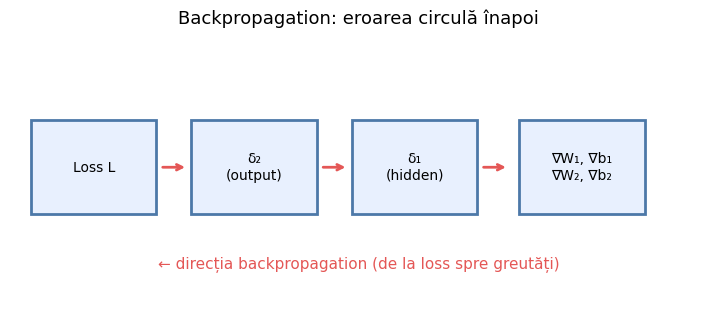

In [12]:
# Vizualizare: fluxul erorii (backprop)
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis("off")
ax.set_title("Backpropagation: eroarea circulă înapoi", fontsize=13)

boxes = [
    (1.2, 2, "Loss L"),
    (3.5, 2, "δ₂\n(output)"),
    (5.8, 2, "δ₁\n(hidden)"),
    (8.2, 2, "∇W₁, ∇b₁\n∇W₂, ∇b₂"),
]
for px, py, txt in boxes:
    ax.add_patch(plt.Rectangle((px - 0.9, py - 0.7), 1.8, 1.4,
                               facecolor="#E8F0FE", edgecolor="#4C78A8", lw=2, zorder=2))
    ax.text(px, py, txt, ha="center", va="center", fontsize=10, zorder=3)

for x_start in [2.15, 4.45, 6.75]:
    ax.annotate("", xy=(x_start + 0.4, 2), xytext=(x_start, 2),
                arrowprops=dict(arrowstyle="->", color="#E45756", lw=2))

ax.text(5, 0.5, "← direcția backpropagation (de la loss spre greutăți)",
        ha="center", fontsize=11, color="#E45756")
plt.show()

In [13]:
def backward(Y, cache, W2):
    """Calculează gradientele față de W1, b1, W2, b2."""
    X = cache["X"]
    a1 = cache["a1"]
    y_hat = cache["y_hat"]
    n = X.shape[0]

    # 1) eroare la output
    dL_dyhat = (2.0 / n) * (y_hat - Y)          # δ2, shape (n, 1)

    # 2) gradiente strat output
    dW2 = a1.T @ dL_dyhat                       # (2, 1)
    db2 = np.sum(dL_dyhat, axis=0, keepdims=True)

    # 3) eroare propagată în hidden
    da1 = dL_dyhat @ W2.T                       # (n, 2)
    dz1 = da1 * tanh_deriv(a1)                  # ⊙ tanh'

    # 4) gradiente strat hidden
    dW1 = X.T @ dz1                             # (1, 2)
    db1 = np.sum(dz1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2

In [14]:
# Un pas de backprop pe datele curente
dW1, db1, dW2, db2 = backward(Y, cache, W2)

print("Gradiente (magnitudini):")
print("dW1:", dW1.round(4))
print("db1:", db1.round(4))
print("dW2:", dW2.round(4))
print("db2:", db2.round(4))

Gradiente (magnitudini):
dW1: [[-0.5412 -1.4087]]
db1: [[-0.0105 -0.0014]]
dW2: [[-0.4468]
 [ 0.1286]]
db2: [[0.0012]]


## Pasul 9 — Actualizarea greutăților (Gradient Descent)

$$
\theta \leftarrow \theta - \alpha \cdot \nabla_\theta L
$$

unde $\alpha$ = **learning rate** (cât de mari sunt pașii).

In [15]:
def update_params(W1, b1, W2, b2, grads, lr):
    dW1, db1, dW2, db2 = grads
    W1 = W1 - lr * dW1
    b1 = b1 - lr * db1
    W2 = W2 - lr * dW2
    b2 = b2 - lr * db2
    return W1, b1, W2, b2

## Pasul 10 — Antrenarea (bucla completă)

La fiecare epocă:
1. **Forward** → predicții
2. **Loss** → cât de greșit suntem
3. **Backward** → gradiente
4. **Update** → corectăm greutățile

In [16]:
def train(X, Y, epochs=2000, lr=0.1, print_every=400):
    W1, b1, W2, b2 = init_params()
    history = []
    snapshots = {}  # predicții la câteva epoci, pentru vizualizare

    for epoch in range(epochs + 1):
        y_hat, cache = forward(X, W1, b1, W2, b2)
        loss = mse_loss(y_hat, Y)
        history.append(loss)

        if epoch in (0, 50, 200, 500, epochs):
            snapshots[epoch] = y_hat.copy()

        if epoch % print_every == 0:
            print(f"Epoca {epoch:4d} | Loss = {loss:.6f}")

        if epoch == epochs:
            break

        grads = backward(Y, cache, W2)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, grads, lr)

    return (W1, b1, W2, b2), history, snapshots

params, history, snapshots = train(X, Y, epochs=2000, lr=0.15)
W1, b1, W2, b2 = params

Epoca    0 | Loss = 1.279636
Epoca  400 | Loss = 0.083246
Epoca  800 | Loss = 0.076170
Epoca 1200 | Loss = 0.042017
Epoca 1600 | Loss = 0.028543
Epoca 2000 | Loss = 0.025929


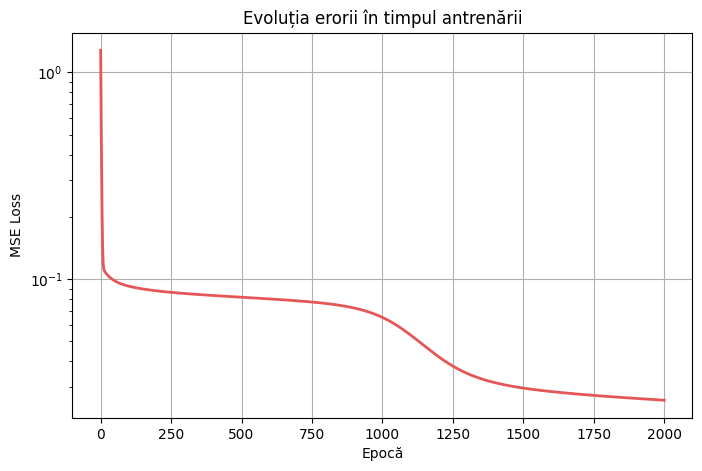

Loss final: 0.025929


In [17]:
plt.plot(history, color="#E45756", lw=2)
plt.xlabel("Epocă")
plt.ylabel("MSE Loss")
plt.title("Evoluția erorii în timpul antrenării")
plt.yscale("log")
plt.show()

print(f"Loss final: {history[-1]:.6f}")

## Pasul 11 — Cum învață rețeaua (vizual)

Vedem predicțiile la câteva momente din antrenare — curba se apropie de puncte.

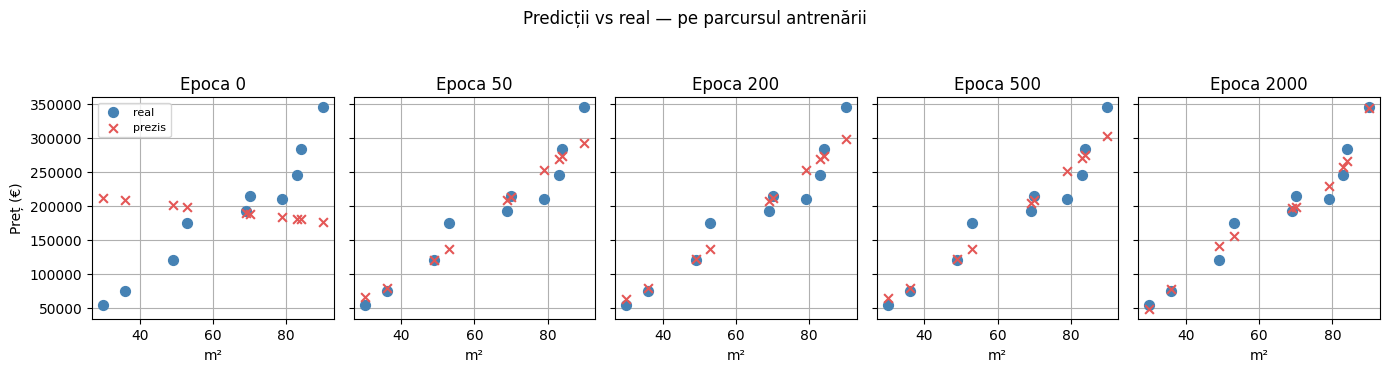

In [18]:
# Linie densă pe axa x pentru a desena curba învățată
x_line = np.linspace(x.min() - 5, x.max() + 5, 200)
x_line_norm = ((x_line - x_mean) / x_std).reshape(-1, 1)

fig, axes = plt.subplots(1, len(snapshots), figsize=(14, 3.5), sharey=True)

for ax, (epoch, y_hat_snap) in zip(axes, snapshots.items()):
    # Pentru epoci intermediare refacem predicția pe linia densă cu params finali
    # (snapshots sunt pe punctele de date; pentru curba folosim params finali doar la ultima)
    ax.scatter(x, y, s=50, color="steelblue", zorder=3, label="real")
    # Predicții pe punctele de antrenare, convertite în euro
    y_pred_eur = y_hat_snap.ravel() * y_std + y_mean
    ax.scatter(x, y_pred_eur, s=40, color="#E45756", marker="x", zorder=4, label="prezis")
    ax.set_title(f"Epoca {epoch}")
    ax.set_xlabel("m²")

axes[0].set_ylabel("Preț (€)")
axes[0].legend(fontsize=8)
plt.suptitle("Predicții vs real — pe parcursul antrenării", y=1.05)
plt.tight_layout()
plt.show()

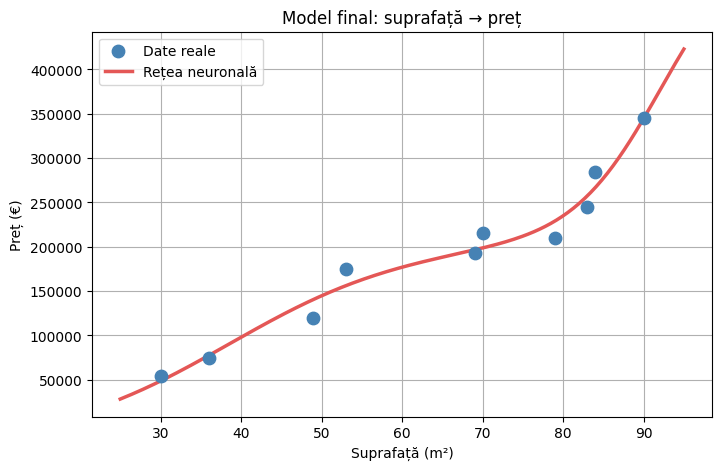

In [19]:
# Curba finală a modelului
y_line_hat, _ = forward(x_line_norm, W1, b1, W2, b2)
y_line_eur = y_line_hat.ravel() * y_std + y_mean

y_train_hat, _ = forward(X, W1, b1, W2, b2)
y_train_eur = y_train_hat.ravel() * y_std + y_mean

plt.scatter(x, y, s=80, color="steelblue", zorder=3, label="Date reale")
plt.plot(x_line, y_line_eur, color="#E45756", lw=2.5, label="Rețea neuronală")
plt.xlabel("Suprafață (m²)")
plt.ylabel("Preț (€)")
plt.title("Model final: suprafață → preț")
plt.legend()
plt.show()

## Pasul 12 — Tabel comparație: real vs prezis

In [20]:
rezultat = pd.DataFrame({
    "suprafata_m2": x.astype(int),
    "pret_real": y.astype(int),
    "pret_prezis": np.round(y_train_eur).astype(int),
})
rezultat["eroare"] = rezultat["pret_prezis"] - rezultat["pret_real"]
rezultat["eroare_%"] = (rezultat["eroare"] / rezultat["pret_real"] * 100).round(1)
rezultat

,suprafata_m2,pret_real,pret_prezis,eroare,eroare_%
0,30,54000,48551,-5449,-10.1
1,36,75000,77405,2405,3.2
2,49,120000,140563,20563,17.1
3,53,175000,156010,-18990,-10.9
4,69,193000,196448,3448,1.8
5,70,215000,198614,-16386,-7.6
6,79,210000,229047,19047,9.1
7,83,245000,257297,12297,5.0
8,84,284000,266723,-17277,-6.1
9,90,345000,344570,-430,-0.1


In [21]:
mae = np.mean(np.abs(y_train_eur - y))
print(f"Eroare medie absolută (MAE): {mae:,.0f} €")

Eroare medie absolută (MAE): 11,629 €


## Pasul 13 — Predicție pe un apartament nou

Exemplu: ce preț ar estima rețeaua pentru **60 m²**?

In [22]:
def predict_pret(suprafata_m2, params):
    W1, b1, W2, b2 = params
    x_n = np.array([[(suprafata_m2 - x_mean) / x_std]])
    y_hat, _ = forward(x_n, W1, b1, W2, b2)
    return float(y_hat[0, 0] * y_std + y_mean)

nou = 60
pret_nou = predict_pret(nou, params)
print(f"Pentru un apartament de {nou} m², preț estimat ≈ {pret_nou:,.0f} €")

Pentru un apartament de 60 m², preț estimat ≈ 176,905 €


## Pasul 14 — Legătura cu gradient descent-ul din notebook-ul anterior

| Concept | Regresie liniară (GD) | Rețea neuronală |
|---|---|---|
| Model | $\hat{y} = ax + b$ | lanț de matrici + activări |
| Parametri | `a`, `b` | `W1`, `b1`, `W2`, `b2` |
| Forward | o singură formulă | mai multe straturi |
| Backward | derivate directe | **backpropagation** (regula lanțului) |
| Update | $a \leftarrow a - \alpha \nabla a$ | același principiu, pe toate greutățile |

Backpropagation este doar **gradient descent pe o rețea cu mai multe straturi**.

## Rezumat (ce am făcut)

1. Am luat aceleași date de apartamente.
2. Am definit o rețea mică: **1 input → 2 neuroni (tanh) → 1 output**.
3. **Forward pass**: calculăm predicția.
4. **Loss (MSE)**: măsurăm eroarea.
5. **Backpropagation**: calculăm gradientele cu regula lanțului.
6. **Update**: corectăm greutățile cu learning rate.
7. Repetăm → rețeaua învață să estimeze prețul.

Totul doar cu **numpy**, **pandas** și **matplotlib**.